In [267]:
import pandas as pd

In [268]:
import numpy as np


In [269]:
import matplotlib.pyplot as plt


In [270]:
import seaborn as sns

In [271]:
from sklearn.preprocessing import LabelEncoder

In [272]:
from sklearn.preprocessing import StandardScaler

In [273]:
from sklearn.ensemble import RandomForestClassifier

In [274]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

In [275]:
from sklearn.model_selection import cross_val_score

In [276]:
pip install xgboost

In [277]:
from xgboost import XGBClassifier

In [278]:
data = pd.read_csv("/content/Train_data.csv")

In [279]:
data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [280]:
data.duplicated().sum()

np.int64(0)

In [281]:
data.shape

(25192, 42)

In [282]:
data.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


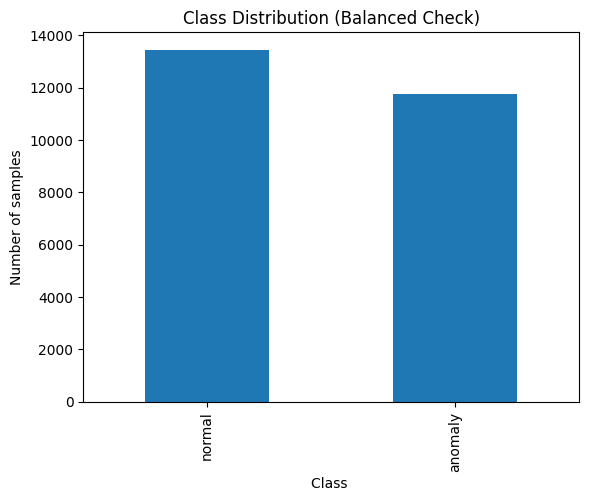

In [283]:
data["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution (Balanced Check)")
plt.xlabel("Class ")
plt.ylabel("Number of samples")
plt.show()

In [284]:
count = data['class'].value_counts()
print(count)

class
normal     13449
anomaly    11743
Name: count, dtype: int64


In [285]:
normal = data[data['class'] == 'normal']

In [286]:
anomaly = data[data['class'] == 'anomaly']

In [287]:
normal_sampled = normal.sample(n=len(anomaly), random_state=42)

In [288]:
balanced_data = pd.concat([normal_sampled, anomaly])

In [289]:
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

In [290]:
print(balanced_data['class'].value_counts())

class
normal     11743
anomaly    11743
Name: count, dtype: int64


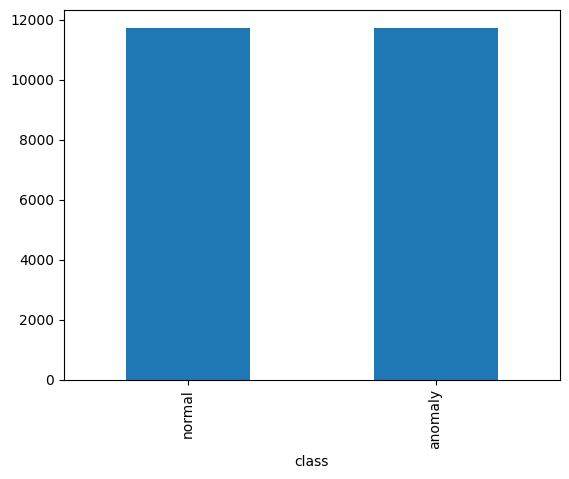

In [291]:
balanced_data['class'].value_counts().plot(kind='bar')
plt.show()

In [292]:
df = balanced_data.copy()

In [293]:
label_encoder = LabelEncoder()

In [294]:
categorical_columns = ['protocol_type', 'service', 'flag', 'class']

In [295]:
for col in categorical_columns:
  df[col] = label_encoder.fit_transform(df[col])

In [296]:
correlation_matrix = df.corr()

In [297]:
class_correlation = correlation_matrix['class'].sort_values(ascending=False).round(4)
print(class_correlation)

class                          1.0000
same_srv_rate                  0.7425
dst_host_srv_count             0.7260
logged_in                      0.6997
dst_host_same_srv_rate         0.6927
flag                           0.6485
protocol_type                  0.2862
srv_diff_host_rate             0.1238
is_guest_login                 0.0409
num_access_files               0.0383
su_attempted                   0.0268
root_shell                     0.0212
num_root                       0.0208
num_compromised                0.0196
num_file_creations             0.0189
num_shells                     0.0152
hot                            0.0140
dst_bytes                      0.0117
land                          -0.0000
num_failed_logins             -0.0020
srv_count                     -0.0034
src_bytes                     -0.0054
urgent                        -0.0065
duration                      -0.0488
dst_host_srv_diff_host_rate   -0.0622
dst_host_same_src_port_rate   -0.0908
wrong_fragme

In [298]:
data = balanced_data.drop(columns=['num_outbound_cmds', 'is_host_login'])

In [299]:
data.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'is_guest_login', 'count', 'srv_count',
       'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
       'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
       'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')

In [300]:
selected_features = [
    'same_srv_rate',
    'dst_host_srv_count',
    'logged_in',
    'dst_host_same_srv_rate',
    'serror_rate',
    'srv_serror_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'count',
    'dst_host_count',
    'dst_host_rerror_rate',
    'rerror_rate',
    'srv_rerror_rate'
]

In [301]:
X = data[selected_features]
Y = data['class']

In [302]:
X_columns = X.columns.tolist()

In [303]:
X_columns

['same_srv_rate',
 'dst_host_srv_count',
 'logged_in',
 'dst_host_same_srv_rate',
 'serror_rate',
 'srv_serror_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'count',
 'dst_host_count',
 'dst_host_rerror_rate',
 'rerror_rate',
 'srv_rerror_rate']

In [304]:
Y = label_encoder.fit_transform(Y)

In [305]:
scaler = StandardScaler()

In [306]:
X = scaler.fit_transform(X)

In [307]:
model_1 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model_1.fit(X,Y)

RandomForestClassifier(random_state=42)

In [308]:
test_data = pd.read_csv('/content/Train_data.csv')

In [309]:
test_data.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [310]:
test_data.duplicated().sum()

np.int64(0)

In [311]:
test_data.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [312]:
test_data.shape

(25192, 42)

In [313]:
test_data = test_data.drop(columns=['num_outbound_cmds', 'is_host_login'])

In [314]:
test_data.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'is_guest_login', 'count', 'srv_count',
       'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
       'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
       'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')

In [315]:
selected_features_test = [
    'same_srv_rate',
    'dst_host_srv_count',
    'logged_in',
    'dst_host_same_srv_rate',
    'serror_rate',
    'srv_serror_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'count',
    'dst_host_count',
    'dst_host_rerror_rate',
    'rerror_rate',
    'srv_rerror_rate'
]

In [316]:
X_test = test_data[selected_features_test]

In [317]:
Y_test = test_data['class']

In [318]:
Y_test = label_encoder.transform(Y_test)

In [319]:
X_test = scaler.transform(X_test)

In [320]:
Y_pred = model_1.predict(X_test)

In [321]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))

Accuracy: 0.9939266433788504


In [322]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     11743
           1       0.99      0.99      0.99     13449

    accuracy                           0.99     25192
   macro avg       0.99      0.99      0.99     25192
weighted avg       0.99      0.99      0.99     25192



In [323]:
print("Train accuracy:", model_1.score(X, Y))
print("Test accuracy:", model_1.score(X_test, Y_test))

Train accuracy: 0.9949331516648215
Test accuracy: 0.9939266433788504


In [324]:
scores = cross_val_score(model_1, X, Y, cv=10)

In [325]:
print("CV Scores:", scores)

CV Scores: [0.97786292 0.98126862 0.97573436 0.97743721 0.97999149 0.97956577
 0.97487223 0.9774276  0.97998296 0.98168654]


In [326]:
print("Mean CV Score:", scores.mean())

Mean CV Score: 0.978582970171801


In [327]:
model_2 = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)


In [328]:
model_2.fit(X,Y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [329]:
Y_pred_2 = model_2.predict(X_test)

In [330]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_2))
print(confusion_matrix(Y_test, Y_pred_2))
print(classification_report(Y_test, Y_pred_2))

Accuracy: 0.9840425531914894
[[11468   275]
 [  127 13322]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98     11743
           1       0.98      0.99      0.99     13449

    accuracy                           0.98     25192
   macro avg       0.98      0.98      0.98     25192
weighted avg       0.98      0.98      0.98     25192



In [331]:
import joblib

In [332]:
joblib.dump(model_1, "random_forest.pkl")
joblib.dump(model_2, "xgboost.pkl")

['xgboost.pkl']

In [333]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_columns, "columns.pkl")

['columns.pkl']

In [334]:
from google.colab import files

files.download("random_forest.pkl")
files.download("xgboost.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>